In [ ]:
!pip install astropy
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
import scipy 
import urllib.request
import os 


In [26]:
NGC2660_555_fits = "hst_10634_03_acs_wfc_f555w_j9dm03_drc.fits"
NGC2660_814_fits = "hst_10634_03_acs_wfc_f814w_j9dm03_drc.fits"
NGC2660_fits = "hst_10634_03_acs_wfc_total_j9dm03.fits"
NGC2660_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&dataset=hst_10634_03_acs_wfc_total_j9dm03"
NGC2660_555_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&download=1&dataset=hst_10634_03_acs_wfc_total_j9dm03&filename=hst_10634_03_acs_wfc_f555w_j9dm03_drc.fits"
NGC2660_814_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&download=1&dataset=hst_10634_03_acs_wfc_total_j9dm03&filename=hst_10634_03_acs_wfc_f814w_j9dm03_drc.fits"

if not os.path.exists(NGC2660_814_fits) & os.path.exists(NGC2660_555_fits):
        try:
            urllib.request.urlretrieve(NGC2660_814_fits_url, NGC2660_814_fits)
            print(f"Downloaded {NGC2660_814_fits}")
            urllib.request.urlretrieve(NGC2660_555_fits_url, NGC2660_555_fits)
            print(f"Downloaded {NGC2660_555_fits}")
        except Exception as e:
            print("Error Downloading File")
            NGC2660_555_fits = None
            NGC2660_814_fits = None

Filename: hst_10634_03_acs_wfc_f814w_j9dm03_drc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     858   ()      
  1  SCI           1 ImageHDU        90   (5383, 5398)   float32   
  2  WHT           1 ImageHDU        45   (5383, 5398)   float32   
  3  CTX           1 ImageHDU        38   (5383, 5398)   int32   
  4  HDRTAB        1 BinTableHDU    638   4R x 314C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 23A, D, D, D, D, K, K, K, 8A, K, 23A, 9A, 20A, K, 4A, K, K, K, K, K, K, 23A, D, D, D, D, K, K, 3A, 3A, 4A, 4A, L, D, D, D, 3A, 1A, K, D, D, D, 24A, 3A, 4A, 4A, 12A, 12A, 23A, 8A, 23A, 10A, 10A, D, D, 3A, 3A, 23A, 4A, 8A, 7A, 23A, D, K, D, 6A, 9A, 8A, D, D, L, 4A, 44A, 3A, K, 7A, 5A, 3A, D, 13A, 8A, 4A, 3A, L, K, L, K, L, K, K, D, D, D, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, 23A, L, 1A, 3A, 1A, D, 3A, 6A, K, D, D, D, D, D, D, D, D, D, D, 23A,

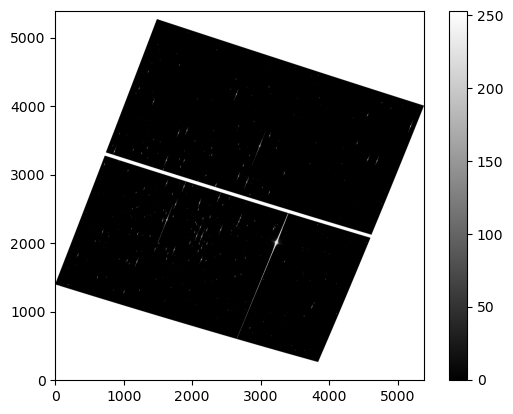

In [39]:
from matplotlib.colors import LogNorm

HDUList = fits.open(NGC2660_814_fits)

HDUList.info()

image_data = HDUList[1].data #reads the data from the SCI section of the fits file
print(image_data)
plt.figure()
plt.imshow(image_data, cmap='gray', origin = 'lower')
plt.colorbar(norm=LogNorm())
plt.show()

HDUList.close()


sigma = 3
fwhm = 2.355 * sigma


In [46]:
import array


clipped_data = image_data.copy()
for i in range(5):
    mean = np.nanmean(clipped_data)
    std = np.nanstd(clipped_data)
    mask = np.abs(clipped_data - mean) <= 3 * std
    clipped_data = clipped_data[mask]
background_mean = np.mean(clipped_data)

print(clipped_data)
print(mask)





#gaussian_PSF

[0.11338808 0.11203732 0.11942384 ... 0.08253482 0.07630425 0.07630425]
[ True  True  True ...  True  True  True]


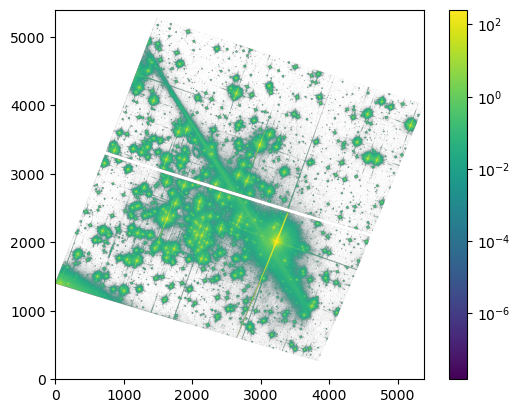

(array([2.660000e+02, 1.978000e+03, 5.073900e+04, 1.102104e+06,
        4.779686e+06, 4.292947e+06, 1.979204e+06, 1.001434e+06,
        5.896490e+05, 3.880360e+05, 2.807050e+05, 2.149840e+05,
        1.700370e+05, 1.371730e+05, 1.130980e+05, 9.576800e+04,
        8.194300e+04, 7.012600e+04, 6.108900e+04, 5.313900e+04,
        4.680900e+04, 4.160400e+04, 3.676000e+04, 3.334500e+04,
        3.010500e+04, 2.743300e+04, 2.513100e+04, 2.316000e+04,
        2.114300e+04, 1.964200e+04, 1.798500e+04, 1.673600e+04,
        1.567200e+04, 1.491500e+04, 1.395400e+04, 1.308800e+04,
        1.225200e+04, 1.176400e+04, 1.100700e+04, 1.052900e+04,
        9.831000e+03, 9.311000e+03, 8.787000e+03, 8.392000e+03,
        8.028000e+03, 7.815000e+03, 7.292000e+03, 7.108000e+03,
        6.771000e+03, 6.569000e+03]),
 array([-0.1       , -0.083     , -0.066     , -0.049     , -0.032     ,
        -0.015     ,  0.002     ,  0.019     ,  0.036     ,  0.053     ,
         0.07      ,  0.087     ,  0.104     ,  

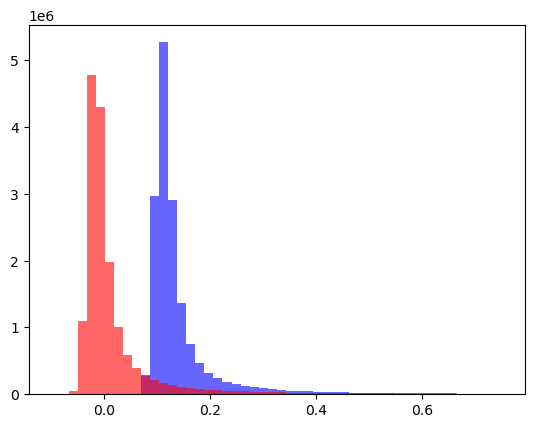

In [48]:
subtracted_image = image_data - background_mean

plt.figure()
plt.imshow(subtracted_image, cmap='viridis', origin = 'lower', norm=LogNorm())
plt.colorbar(norm=LogNorm())
plt.show()

fig, axes = plt.subplots()
axes.hist(image_data.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
axes.hist(subtracted_image.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

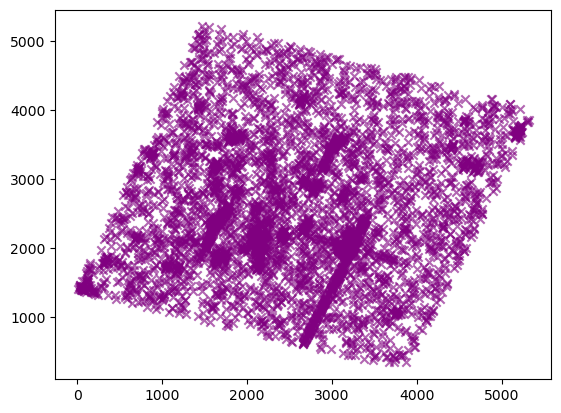

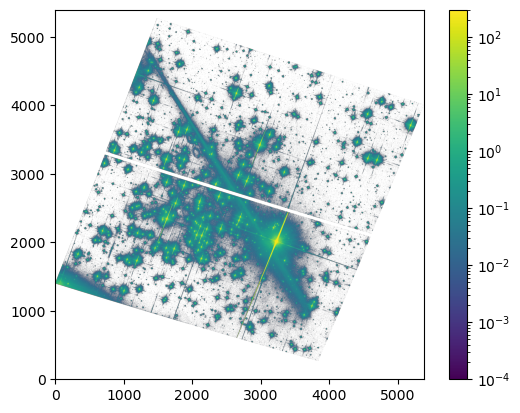

In [53]:
subtracted_image = image_data - background_mean

detection_threshold = 5 * background_mean

filter = int(np.ceil(fwhm))

local_max = scipy.ndimage.maximum_filter(subtracted_image, size=filter)

peaks = (subtracted_image == local_max) & (subtracted_image > detection_threshold)

detections_y, detections_x = np.where(peaks)

fig, axes = plt.subplots()

plt.figure()
plt.imshow(subtracted_image, cmap='viridis', origin = 'lower', norm=LogNorm(vmin = .0001, vmax=300))
axes.scatter(detections_x, detections_y, color = 'purple', alpha =.6, marker='x')
plt.colorbar(norm=LogNorm(vmin = .0001, vmax=300))
plt.show()


#axes[2].hist(image_data.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
#axes[2].hist(subtracted_image.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

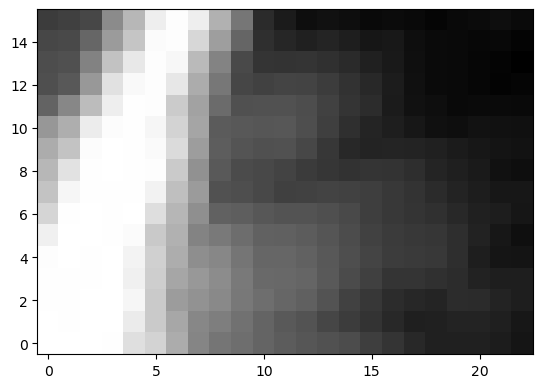

In [ ]:
section_1 = subtracted_image[1311, 1231]
section_2 = subtracted_image[544, 3297]
section_3 = subtracted_image[2910, 4128]
section_4 = subtracted_image[4462, 1557]
section_5 = subtracted_image[1657, 2605]
section_6 = subtracted_image[4064, 1437]
section_7 = subtracted_image[2160 , 690]
section_8 = image_data[4531, 1714]
section_9 = image_data[2010, 3225]
section_10 = image_data[2710, 1710]
section_11 = image_data[4531, 1713]
section_12 = image_data[4168, 2647]
section_13 = image_data[]
plt.figure()
plt.imshow(section_6, cmap='gray', origin = 'lower', norm=LogNorm())
plt.show()

In [ ]:
class star
    
